In [1]:
import sys
from pathlib import Path
# Make the repo root importable regardless of CWD or machine: walk up from the
# working dir until we hit a repo marker, then put that dir on sys.path.
_start = Path.cwd()
_root = next((p for p in (_start, *_start.parents)
              if (p / ".git").exists() or (p / "setup.py").exists()), _start)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
from metab_processing.metab_travlr_config import PROJECT_DATA_DIR, DATA_DIR as METAB_DATA_DIR

XENIUM_DATA_DIR = PROJECT_DATA_DIR
DATASET_NAME = 'Primary_Dermal_Melanoma'
DATA_DIR = f'{XENIUM_DATA_DIR}/{DATASET_NAME}'

In [2]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

In [4]:
# This is for loading the coefficients into the adata, which requires spacetravlr to be installed (or at least some of its required arrays)

# adata = sc.read_h5ad(f'{DATA_DIR}/adata.h5ad')
# adata

# from metab_processing.SpaceTravLR import beta_analysis

# betadata_dir = f'{DATA_DIR}/spacetravlr_output/betadata'
# beta_analysis.betas_to_adata(adata, betadata_dir, group=None)
# print(adata)
# adata.write_h5ad(f"{DATA_DIR}/spacetravlr_adata.h5ad")
# del adata

In [3]:
adata = sc.read_h5ad(f'{DATA_DIR}/spacetravlr_adata.h5ad')
adata

AnnData object with n_obs × n_vars = 112551 × 5006
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', '_scvi_batch', '_scvi_labels', 'leiden_scVI_res_0.5', 'leiden_scVI_res_2.5', 'leiden_scVI_res_2', 'leiden_scVI_res_1.5', 'leiden_scVI_res_1', 'leiden_scVI_res_0.75', 'leiden_scVI_res_0.65', 'leiden_scVI_res_0.375', 'leiden_scVI_res_0.25', 'leiden_scVI_res_0.1', 'leiden_scVI_res_0.05', 'cd8', 'cd4', 't_cell', 'Tier1', 'Tier2', 'Tier3', 'Cytotoxic_CD8_score', 'Exhausted_CD8_score', 'Treg_score', 'sub_cluster_5_res_1', 'sub_cluster_5_res_0.75', 'sub_cluster_5_res_0.5', 'sub_cluster_5_res_0.37', 'sub_cluster_5_res_0.25', 'sub_cluster_5_res_0.15', 'sub_cluster_5_res_0.1', 'sub_cluster_5_res_0.05', 'sub_cluster_2_res_1', 'sub_cluster_2_res_0.75', 'sub_cluster_2_res_0

/tmp/ipykernel_305878/4166114895.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='Tier3');


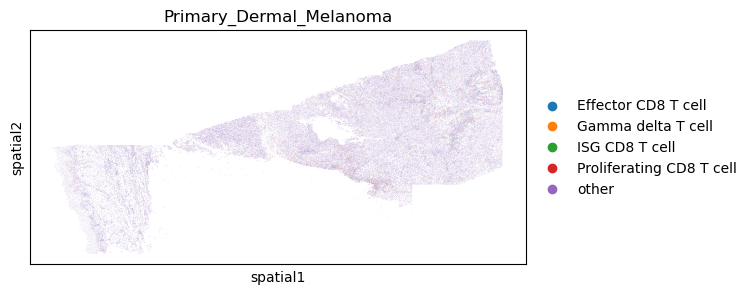

In [4]:
sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='Tier3');

/tmp/ipykernel_305878/679526146.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


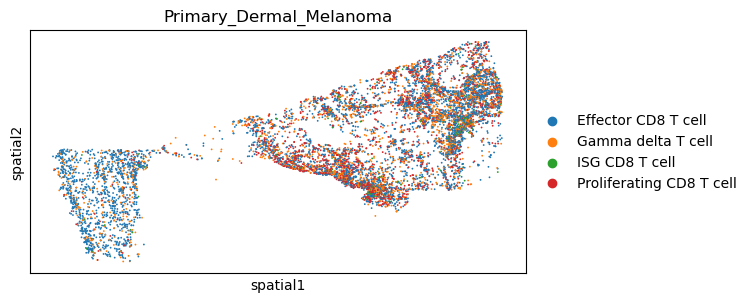

In [5]:
sc.pl.spatial(
    adata[adata.obs['Tier3'] != 'other'], 
    spot_size=35, 
    show=False, 
    title=DATASET_NAME, 
    color='Tier3'
);

In [6]:
list(adata.uns['beta_modulators'])

['CD3E',
 'CD3G',
 'CD4',
 'CTLA4',
 'ENTPD1',
 'FOXP3',
 'HAVCR2',
 'HIF1A',
 'IL10',
 'IL2RA',
 'LAG3',
 'MYC',
 'PDCD1',
 'TBP',
 'TCF7',
 'TOX']

In [11]:
GENE = 'MYC'
adata.uns['beta_modulators'][GENE]

array(['ARX', 'ATF3', 'BATF', 'CREB3', 'E2F1', 'E2F3', 'E2F4', 'EBF1',
       'EGR2', 'EGR3', 'EGR4', 'ELK1', 'EN2', 'EP300', 'ERG', 'ETS1',
       'FEV', 'FLI1', 'FOSL1', 'FOXA1', 'FOXA2', 'FOXD2', 'FOXE1',
       'FOXE3', 'FOXI1', 'FOXJ2', 'FOXL2', 'GSX2', 'GTF2I', 'HDAC2',
       'HEY1', 'HMGN3', 'HNF4A', 'HOXA5', 'HOXB5', 'HOXB6', 'IRF1',
       'JDP2', 'LBX1', 'MAF', 'MAFB', 'MAFF', 'MAX', 'MEF2A', 'MEF2C',
       'MYBL2', 'MYEF2', 'NF1', 'NFKB1', 'NR1H3', 'NR1H4', 'NR2C2',
       'NR3C1', 'NRF1', 'PAX6', 'PDX1', 'PLAGL1', 'POU1F1', 'POU2F2',
       'POU3F1', 'POU3F3', 'POU3F4', 'POU4F3', 'PRDM1', 'RHOXF2', 'RXRA',
       'SMAD1', 'SMAD3', 'SMAD4', 'SMARCB1', 'SMARCC1', 'SMC3', 'SP1',
       'SP3', 'SP9', 'SRF', 'STAT3', 'TAF1', 'TAL1', 'TCF7L2', 'TFAP2A',
       'TFAP2B', 'TRIM28', 'VAX1', 'VDR', 'VSX2', 'WT1', 'XBP1', 'YY1',
       'ZBTB1', 'ZBTB33', 'ZIC4', 'ZNF281', 'BMP8B$BMPR2', 'GDF15$TGFBR2',
       'ANGPTL4$ITGB3', 'POSTN$ITGAV', 'POSTN$ITGB3', 'POSTN$ITGB5',
       'SEMA

In [10]:
def plot_beta(adata, gene, modulator, tier, cell_types=None, spot_size=35):
    i = (adata.uns['beta_modulators'][gene] == modulator).argmax()
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    sub = sub[:, :1].copy()
    sub.obs['beta'] = sub.obsm[f'beta_{gene}'][:, i]
    sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,
                  title=f'{gene} ~ {modulator} ({tier})')

/tmp/ipykernel_3208654/4168805372.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,
/tmp/ipykernel_3208654/4168805372.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,
/tmp/ipykernel_3208654/4168805372.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,


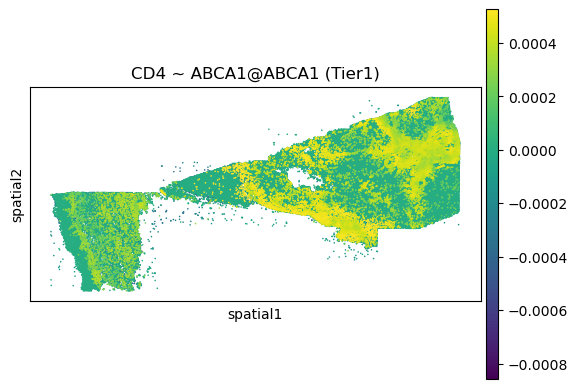

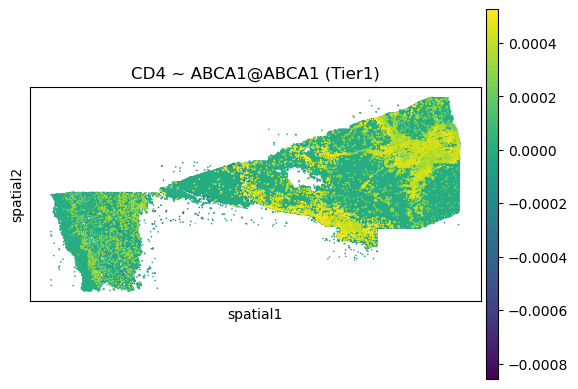

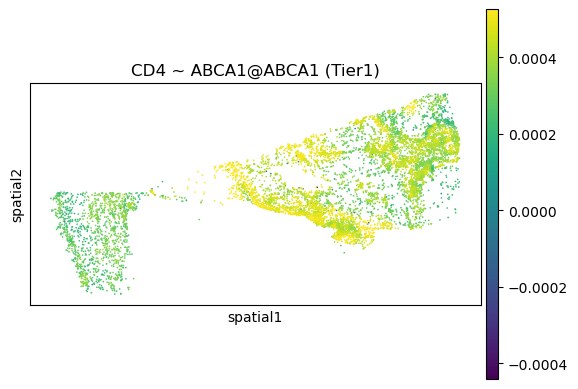

In [11]:
gp = [m for m in adata.uns['beta_modulators'][GENE] if '@' in m][0]
plot_beta(adata, GENE, gp, 'Tier1', ['T Cell', 'other'])
plot_beta(adata, GENE, gp, 'Tier1', ['other'])
plot_beta(adata, GENE, gp, 'Tier1', ['T Cell'])

In [8]:
adata.uns['beta_modulators']['FOXP3'] # Note that this demonstrates that we have no metabolite gene pairs (indicated with @),
# ie all the gps were zeroed out in training. This also shows that if we have a beta_modulator, then it is non zero on some cell

array(['AR', 'BCL3', 'CTCF', 'CTCFL', 'EBF1', 'EGR2', 'EGR3', 'EGR4',
       'ESR2', 'FOXA1', 'FOXD2', 'FOXE1', 'FOXE3', 'FOXI1', 'FOXL2',
       'GATA2', 'GATA3', 'HDAC2', 'HIVEP2', 'KLF5', 'MAX', 'NFATC1',
       'NFATC2', 'NFATC3', 'NFATC4', 'NFKB1', 'NR3C1', 'NR3C2', 'NRF1',
       'PAX5', 'PAX7', 'PGR', 'POU5F1', 'RBPJ', 'REL', 'REST', 'RFX1',
       'RXRA', 'SMC3', 'SOX18', 'SRF', 'TAL1', 'TBX2', 'TBX21', 'TBX4',
       'TBX5', 'TP63', 'ZIC4', 'ZNF281', 'TGFB1$TGFBR2', 'TGFB3$TGFBR1',
       'TGFB3$TGFBR2', 'BMP8B$BMPR2', 'GDF15$TGFBR2', 'INHBA$ACVR2A',
       'WNT2$FZD1', 'WNT5A$FZD1', 'FGF1$FGFR1', 'FGF2$FGFR1',
       'FGF7$FGFR1', 'PDGFA$PDGFRA', 'PDGFA$PDGFRB', 'PDGFB$PDGFRA',
       'PDGFB$PDGFRB', 'PDGFC$PDGFRA', 'PDGFD$PDGFRB', 'CCL8$CCR1',
       'CCL13$CCR1', 'CCL8$CCR2', 'CCL22$CCR4', 'CXCL9$CXCR3',
       'CXCL10$CXCR3', 'CXCL11$CXCR3', 'CXCL13$CXCR3', 'CXCL12$CXCR4',
       'CXCL11$ACKR3', 'CXCL12$ACKR3', 'CXCL16$CXCR6', 'IL7$IL2RG',
       'IL15$IL2RB', 'IL15$IL2RG'

In [12]:
def get_betas_modulator(adata, gene, modulator, tier, cell_types=None):
    i = (adata.uns['beta_modulators'][gene] == modulator).argmax()
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    sub = sub[:, :1].copy()
    return sub.obsm[f'beta_{gene}'][:, i]

def agg_modulator(adata, gene, modulator, tier, cell_types):
    betas = get_betas_modulator(adata, gene, modulator, tier, cell_types)
    return np.mean(betas), np.std(betas)

agg_modulator(adata, GENE, 'NFKB1', 'Tier3', cell_types=['Effector CD8 T cell'])
        

(np.float32(0.055423677), np.float32(0.017246515))